# Structured Data Analysis and Dimensionality Reduction

**Author:** Phabel Antonio López Delgado, BSc.

This notebook explores the analysis of structured data using Pandas, visualisation with Matplotlib, and dimensionality reduction techniques (PCA and autoencoders). We work with the Breast Cancer Wisconsin (Diagnostic) dataset from Kaggle, which contains features extracted from breast cancer cell nuclei.

**Key Concepts Covered:**
- Loading structured data from Kaggle using `kagglehub`.
- Data preprocessing: handling target columns.
- Descriptive statistics and data exploration.
- Data visualisation: bar charts, histograms, box plots, pie charts.
- Correlation analysis (Pearson).
- Dimensionality reduction using Principal Component Analysis (PCA).
- Implementing PCA using a linear autoencoder in PyTorch.

**Key Techniques & Libraries:**
- `kagglehub` – automatic dataset loading from Kaggle.
- `pandas` – data manipulation and descriptive statistics.
- `matplotlib` – visualisation.
- `sklearn.decomposition.PCA` – PCA implementation.
- `torch` – building a linear autoencoder.

**Objective:**
To become proficient in handling structured data, exploring its properties, visualising patterns, and reducing dimensionality for further analysis.

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import kagglehub
from sqlite3 import connect

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

print("All imports successful.")

All imports successful.


## 1. Data Loading from Kaggle

We download the Breast Cancer Wisconsin (Diagnostic) dataset using `kagglehub`. The dataset contains:
- 569 samples, 30 numeric features (mean, standard error, worst values).
- A target column `diagnosis` with values 'M' (malignant) and 'B' (benign).

We map 'M' → 1, 'B' → 0 and rename the target to `Y`. We also drop the empty `Unnamed: 32` column if present.

In [19]:
# Download dataset from Kaggle
path = kagglehub.dataset_download("uciml/breast-cancer-wisconsin-data")
csv_path = f"{path}/data.csv"

# Load the CSV
dataset = pd.read_csv(csv_path, index_col=0)  # 'id' column as index

print(f"Dataset shape: {dataset.shape}")
print("\nColumn names:")
print(dataset.columns.tolist())

# Drop the empty 'Unnamed: 32' column if it exists
if 'Unnamed: 32' in dataset.columns:
    dataset = dataset.drop('Unnamed: 32', axis=1)

# Create target column: 'Y' (1 for malignant, 0 for benign)
dataset['Y'] = (dataset['diagnosis'] == 'M').astype(int)
dataset = dataset.drop('diagnosis', axis=1)  # remove original diagnosis

print("\nFirst 5 rows:")
dataset.head()

Dataset shape: (569, 32)

Column names:
['diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se', 'fractal_dimension_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst', 'Unnamed: 32']

First 5 rows:


,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Y
id,,,,,,,,,,,,,,,,,,,,,
842302,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,1
842517,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,1
84300903,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,1
84348301,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,1
84358402,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,1


## 2. Convert to PyTorch Tensor

In [20]:
# Select only numeric columns (all are numeric now)
numeric_cols = dataset.select_dtypes(include=[np.number]).columns
data_tensor = torch.tensor(dataset[numeric_cols].to_numpy(), dtype=torch.float32)
print(f"Tensor shape: {data_tensor.shape}")

Tensor shape: torch.Size([569, 31])


## 3. Load from SQL Database (Demo)

In [22]:
# Create an in-memory SQLite database
conn = connect(':memory:')
dataset.to_sql('dataset_db', conn, if_exists='replace', index=False)

# Query the 'Y' column
query_result = pd.read_sql('SELECT Y FROM dataset_db', conn)
print("Query result (first 5 rows):")
query_result.head()

Query result (first 5 rows):


,Y
0,1
1,1
2,1
3,1
4,1


## 4. Data Exploration and Visualisation

We explore the dataset using descriptive statistics and various visualisations.

In [23]:
# Summary statistics
dataset.describe()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Y
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.372583
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,0.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


In [33]:
# Select features for visualisation
data_vis = dataset[['radius_mean', 'texture_mean', 'area_mean', 'radius_worst', 'texture_worst', 'area_worst', 'Y']]

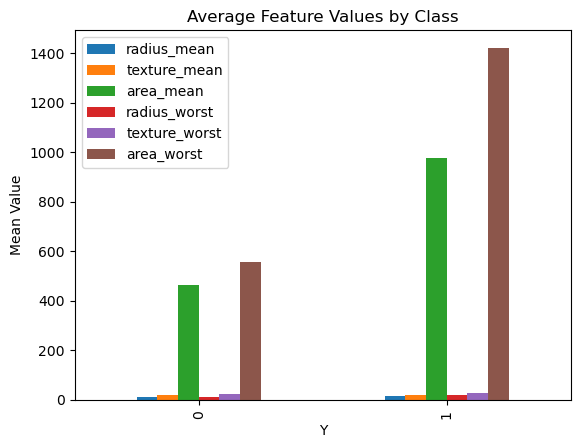

In [25]:
# Bar chart: average values by target class
data_vis.groupby('Y').mean().plot.bar()
plt.title('Average Feature Values by Class')
plt.ylabel('Mean Value')
plt.show()

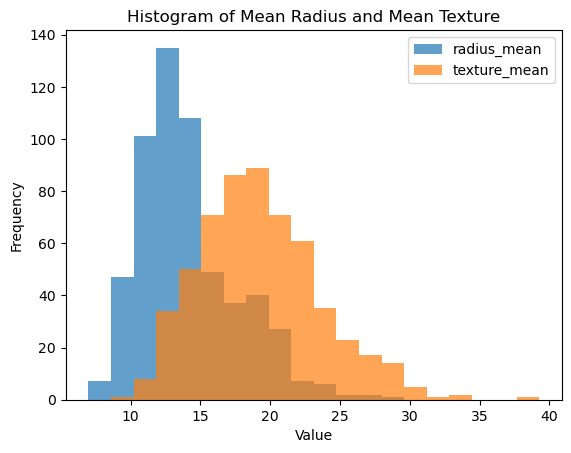

In [26]:
# Histogram of selected features
data_vis[['radius_mean', 'texture_mean']].plot.hist(alpha=0.7, bins=20)
plt.title('Histogram of Mean Radius and Mean Texture')
plt.xlabel('Value')
plt.show()

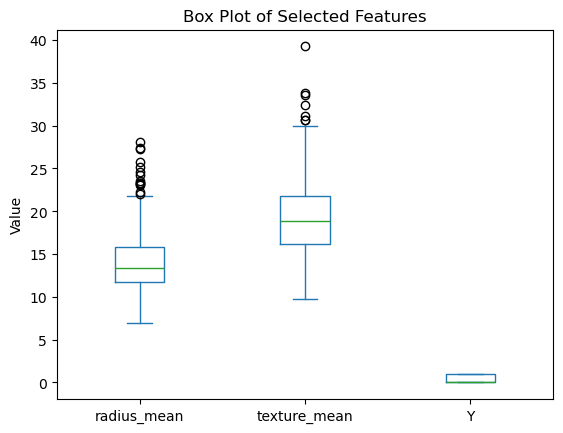

In [27]:
# Box plot of selected features
data_vis[['radius_mean', 'texture_mean', 'Y']].plot.box()
plt.title('Box Plot of Selected Features')
plt.ylabel('Value')
plt.show()

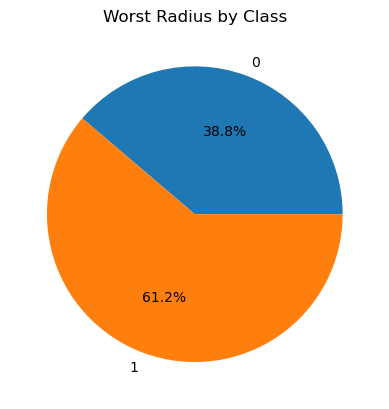

In [28]:
# Pie chart: distribution of 'radius_worst' by class
dataset.groupby('Y').mean()['radius_worst'].plot.pie(autopct='%1.1f%%')
plt.title('Worst Radius by Class')
plt.ylabel('')
plt.show()

## 5. Correlation Analysis

We compute the **Pearson correlation coefficient** between all pairs of selected features. The correlation coefficient \( r \) measures the strength and direction of a linear relationship:

$r = \frac{\sum (x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum (x_i - \bar{x})^2 \sum (y_i - \bar{y})^2}}$

Values close to 1 indicate strong positive correlation, close to -1 indicate strong negative correlation, and 0 indicates no linear correlation.

In [29]:
# Pearson correlation matrix
corr_matrix = data_vis.corr(method='pearson')
print("Pearson Correlation Matrix:")
corr_matrix

Pearson Correlation Matrix:


,radius_mean,texture_mean,area_mean,radius_worst,texture_worst,area_worst,Y
radius_mean,1.000000,0.323782,0.987357,0.969539,0.297008,0.941082,0.730029
texture_mean,0.323782,1.000000,0.321086,0.352573,0.912045,0.343546,0.415185
area_mean,0.987357,0.321086,1.000000,0.962746,0.287489,0.959213,0.708984
radius_worst,0.969539,0.352573,0.962746,1.000000,0.359921,0.984015,0.776454
texture_worst,0.297008,0.912045,0.287489,0.359921,1.000000,0.345842,0.456903
area_worst,0.941082,0.343546,0.959213,0.984015,0.345842,1.000000,0.733825
Y,0.730029,0.415185,0.708984,0.776454,0.456903,0.733825,1.000000


## 6. Dimensionality Reduction with PCA

**Principal Component Analysis (PCA)** is a linear dimensionality reduction technique that finds an orthogonal projection of the data onto a lower‑dimensional space, maximising the variance retained.

The objective is to find a matrix \( U \) (the principal components) such that:

$
U^* = \arg\min_{U} \frac{1}{2} \| X - U^T U X \|^2
$

subject to $ U^T U = I $. The columns of $U$ are the eigenvectors of the covariance matrix of $X$.

We apply PCA to reduce the 30‑dimensional feature space to 2 dimensions for visualisation. We standardise the data first (mean 0, variance 1) because PCA is sensitive to scale.

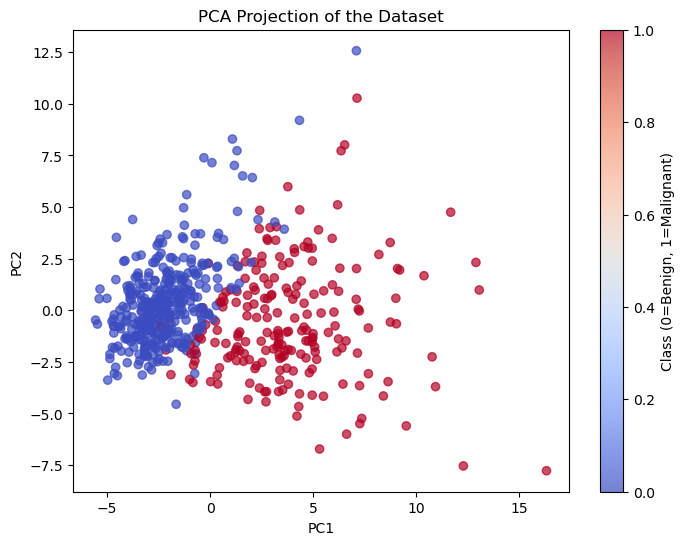

In [30]:
# Separate features and target
X = dataset.iloc[:, :-1].values  # all columns except Y
y = dataset['Y'].values

# Standardise the data (important for PCA)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply PCA (2 components)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Visualise the 2D projection
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='coolwarm', alpha=0.7)
plt.colorbar(label='Class (0=Benign, 1=Malignant)')
plt.title('PCA Projection of the Dataset')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()

## 7. PCA via Autoencoder (Neural Network)

A linear autoencoder with a single hidden layer (no activation) is equivalent to PCA. The encoder maps the input $x$ to a lower‑dimensional latent representation $z = W x$, and the decoder reconstructs $\hat{x} = W^T z$. The loss function is the mean squared error between the input and reconstruction:

$\mathcal{L} = \frac{1}{N} \sum_{i=1}^N \| x_i - W^T W x_i \|^2$

This is exactly the PCA objective. Training the autoencoder via gradient descent yields the same principal components (up to rotation). Here we implement a linear autoencoder in PyTorch.

In [31]:
# Convert data to PyTorch tensors (already scaled)
X_torch = torch.tensor(X_scaled, dtype=torch.float32)

# Define the autoencoder
class LinearAutoencoder(nn.Module):
    def __init__(self, input_dim, latent_dim):
        super(LinearAutoencoder, self).__init__()
        self.encoder = nn.Linear(input_dim, latent_dim, bias=False)
        self.decoder = nn.Linear(latent_dim, input_dim, bias=False)

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return encoded, decoded

# Instantiate the model
input_dim = X_scaled.shape[1]
latent_dim = 2
autoencoder = LinearAutoencoder(input_dim, latent_dim)

# Loss function and optimizer
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(autoencoder.parameters(), lr=0.1)

# Training loop
epochs = 1000
for epoch in range(epochs):
    encoded, decoded = autoencoder(X_torch)
    loss = criterion(decoded, X_torch)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 200 == 0:
        print(f"Epoch {epoch+1}/{epochs}, Loss: {loss.item():.6f}")

Epoch 200/1000, Loss: 0.367594
Epoch 400/1000, Loss: 0.367575
Epoch 600/1000, Loss: 0.367570
Epoch 800/1000, Loss: 0.367569
Epoch 1000/1000, Loss: 0.367585


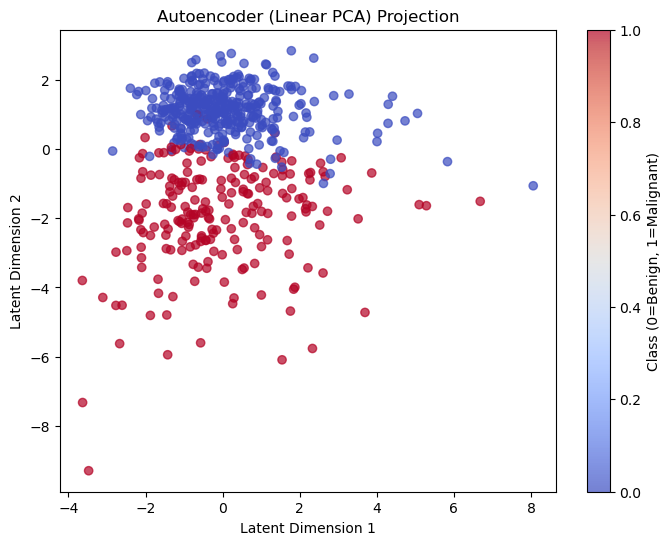

In [32]:
# Extract the latent representation
with torch.no_grad():
    latent_rep, _ = autoencoder(X_torch)

# Visualise the 2D projection
plt.figure(figsize=(8, 6))
plt.scatter(latent_rep[:, 0].numpy(), latent_rep[:, 1].numpy(), c=y, cmap='coolwarm', alpha=0.7)
plt.colorbar(label='Class (0=Benign, 1=Malignant)')
plt.title('Autoencoder (Linear PCA) Projection')
plt.xlabel('Latent Dimension 1')
plt.ylabel('Latent Dimension 2')
plt.show()

## Summary and Next Steps

**Accomplished:**
- Loaded the Breast Cancer Wisconsin dataset from Kaggle using `kagglehub`.
- Preprocessed the data: created a binary target column `Y` and dropped the empty column.
- Explored the dataset with descriptive statistics and visualisations (bar charts, histograms, box plots, pie charts).
- Computed the Pearson correlation matrix.
- Applied PCA to reduce dimensionality and visualise the data in 2D.
- Implemented a linear autoencoder in PyTorch as an alternative to PCA.

**Key Results:**
- The dataset contains 569 samples with 30 numeric features and a binary target (malignant vs benign).
- Visualisations showed clear separability between the two classes.
- Correlation analysis identified strong relationships between certain features.
- Both PCA and the autoencoder projected the data into 2D, preserving class separation.

**Key Insights:**
- `kagglehub` provides a convenient way to load datasets directly from Kaggle.
- The `diagnosis` column (M/B) must be converted to a numeric target for machine learning.
- Standardisation is important before applying PCA to ensure features have equal weight.
- Linear autoencoders learn a projection similar to PCA and can serve as a flexible neural alternative.
- Visualisation tools help identify patterns and outliers in the data.

**Suggested Next Steps:**
1. **Explore non‑linear dimensionality reduction** – apply t‑SNE or UMAP for comparison.
2. **Perform feature selection** – remove highly correlated features to simplify models.
3. **Use the reduced data for classification** – train a classifier (e.g., logistic regression) on the 2D projection.
4. **Experiment with autoencoder architectures** – add non‑linearities (activation functions) to learn more complex representations.
5. **Evaluate reconstruction error** – compare PCA and autoencoder performance.

**Reflection:**
This notebook provides a comprehensive workflow for structured data analysis – from loading and exploration to dimensionality reduction. Understanding the structure and relationships within data is a critical first step in any machine learning project. The visualisation and correlation tools help identify patterns and guide subsequent modelling decisions. The PCA and autoencoder approaches demonstrate both classical and neural methods for dimension reduction, highlighting their similarities and differences.

# Handling Categorical Data for Neural Networks

**Author:** Phabel Antonio López Delgado, BSc.

This part demonstrates how to handle categorical data for machine learning and neural network models. Categorical variables must be converted to numerical representations before they can be used in algorithms.

**Key Concepts Covered:**
- Mapping categories to integers using dictionaries.
- Converting logical (True/False) data to binary.
- Transforming arbitrary categories to integer indices.
- One‑hot encoding using PyTorch.
- Binning (grouping) continuous data into categorical intervals.

**Key Techniques & Libraries:**
- `torch` – tensor operations and one‑hot encoding.
- `pandas` – binning with `cut()`.

**Objective:**
To understand and apply common techniques for converting categorical data into numerical formats suitable for neural networks and machine learning models.

## Why Categorical Data Needs Encoding

Most machine learning algorithms, including neural networks, expect numerical inputs. Categorical data (e.g., colours, names, yes/no responses) must be transformed into numbers. The choice of encoding depends on the nature of the categories:

- **Binary categories** (yes/no, true/false) → map to 0/1.
- **Nominal categories** (no inherent order) → one‑hot encoding.
- **Ordinal categories** (ordered, e.g., low/medium/high) → map to integers or use one‑hot.

In [34]:
import torch
import torch.nn as nn
import pandas as pd

print("All imports successful.")

All imports successful.


## 1. Using Dictionaries for Mapping

The simplest way to convert categorical data is to create a dictionary that maps each category to a numerical value. This works well for:

- Binary categories (yes/no, true/false).
- Ordinal categories where the order matters (e.g., low/medium/high).
- Small sets of known categories.

In [35]:
# Map yes/no to 1/0
binary_map = {'yes': 1, 'no': 0}

original_data = ['no', 'yes', 'yes', 'no']
binary_data = torch.tensor([binary_map[item] for item in original_data])

print("Original data:", original_data)
print("Mapped data:", binary_data)

Original data: ['no', 'yes', 'yes', 'no']
Mapped data: tensor([0, 1, 1, 0])


### Logical (True/False) Data

Booleans can be converted to binary (0/1) by multiplying the tensor by 1. This works because `True` is treated as 1 and `False` as 0 in arithmetic operations.

In [36]:
logical_data = torch.tensor([True, False, True, True])
binary_data = 1 * logical_data

print("Logical data:", logical_data)
print("Binary data:", binary_data)

Logical data: tensor([ True, False,  True,  True])
Binary data: tensor([1, 0, 1, 1])


## 2. Arbitrary Categories – Integer Indexing
When categories are arbitrary (e.g., colours, names), we can assign a unique integer to each category. This is often called label encoding.

For example, we can map 'red' -> 0, 'green' -> 1, 'blue' -> 2.

In [37]:
def categories_to_indices(categorical_data):
    """
    Convert a list of categorical strings to integer indices.

    Args:
        categorical_data (list): list of strings representing categories.

    Returns:
        torch.Tensor: integer indices.
        dict: mapping from category to index.
    """
    category_map = {}
    indices = []

    for item in categorical_data:
        if item not in category_map:
            category_map[item] = len(category_map)
        indices.append(category_map[item])

    return torch.tensor(indices), category_map

In [38]:
colours = ['blue', 'green', 'green', 'red', 'blue', 'yellow']

indices, colour_map = categories_to_indices(colours)
print("Colour map:", colour_map)
print("Indices:", indices)

Colour map: {'blue': 0, 'green': 1, 'red': 2, 'yellow': 3}
Indices: tensor([0, 1, 1, 2, 0, 3])


## 3. One‑Hot Encoding
One‑hot encoding represents each category as a binary vector of length equal to the number of categories. The vector has a 1 at the position corresponding to the category and 0s elsewhere.

For a category with index $k$ and total categories $C$, the one‑hot vector is:

$e_k = [0,0,...,1,...,0]$ with 1 at position $k$

One‑hot encoding is essential for nominal categories where there is no inherent order. It prevents the model from assuming a false ordinal relationship.
In PyTorch, we use ``torch.nn.functional.one_hot()``.

In [39]:
# Convert indices to one-hot vectors
num_classes = len(colour_map)
one_hot = nn.functional.one_hot(indices, num_classes=num_classes)

print("Indices:", indices)
print("One-hot vectors:\n", one_hot)

Indices: tensor([0, 1, 1, 2, 0, 3])
One-hot vectors:
 tensor([[1, 0, 0, 0],
        [0, 1, 0, 0],
        [0, 1, 0, 0],
        [0, 0, 1, 0],
        [1, 0, 0, 0],
        [0, 0, 0, 1]])


## 4. Binning (Grouping) Continuous Data
Binning (also called discretisation) transforms continuous numerical data into categorical intervals. This can be useful for:

* Handling outliers.

* Creating ordinal features.

* Simplifying complex relationships.

In Pandas, we use ``pd.cut()`` to divide data into bins and assign labels.

In [41]:
# Sample continuous data (e.g., ages)
ages = [0, 2, 3, 4, 6, 8, 2, 4, 7, 2, 5, 8, 2, 5, 9, 3]

# Create bins and labels
binned_ages = pd.cut(ages, bins=3, labels=['low', 'medium', 'high'])

print("Original ages:", ages)
print("Binned ages:\n", binned_ages)
print("Categories:", binned_ages.categories)

Original ages: [0, 2, 3, 4, 6, 8, 2, 4, 7, 2, 5, 8, 2, 5, 9, 3]
Binned ages:
 ['low', 'low', 'low', 'medium', 'medium', ..., 'high', 'low', 'medium', 'high', 'low']
Length: 16
Categories (3, object): ['low' < 'medium' < 'high']
Categories: Index(['low', 'medium', 'high'], dtype='object')


## 5. Encoding Binned Data for Neural Networks
Once we have binned data, we can encode it using the same techniques as categorical data, either integer mapping or one‑hot encoding.

In [45]:
# Convert binned data to integers using pandas categorical codes
binned_codes = binned_ages.codes
print("Binned codes:", binned_codes)

# Convert to PyTorch tensor
binned_tensor = torch.tensor(binned_codes, dtype=torch.long)
print("Tensor:", binned_tensor)

# One-hot encode the binned data
num_bins = len(binned_ages.categories)
one_hot_binned = nn.functional.one_hot(binned_tensor, num_classes=num_bins)
print("One-hot encoded bins:\n", one_hot_binned)

Binned codes: [0 0 0 1 1 2 0 1 2 0 1 2 0 1 2 0]
Tensor: tensor([0, 0, 0, 1, 1, 2, 0, 1, 2, 0, 1, 2, 0, 1, 2, 0])
One-hot encoded bins:
 tensor([[1, 0, 0],
        [1, 0, 0],
        [1, 0, 0],
        [0, 1, 0],
        [0, 1, 0],
        [0, 0, 1],
        [1, 0, 0],
        [0, 1, 0],
        [0, 0, 1],
        [1, 0, 0],
        [0, 1, 0],
        [0, 0, 1],
        [1, 0, 0],
        [0, 1, 0],
        [0, 0, 1],
        [1, 0, 0]])


## Summary and Next Steps
Accomplished:

* Converted categorical data to numerical representations using dictionaries.
* Transformed logical (True/False) data to binary.
* Created integer indices for arbitrary categories.
* Applied one‑hot encoding using PyTorch.
* Binned continuous data into categorical intervals using Pandas.
* Encoded binned data for neural network input.

Key Insights:

* Dictionary mapping is simple and works well for binary and ordinal categories.
* Integer indexing (label encoding) is compact but may imply a false order to the model.
* One‑hot encoding is the preferred method for nominal categories, as it avoids introducing ordinal relationships.
* Binning transforms continuous data into categorical groups, which can be useful for handling outliers or creating ordinal features.
* The choice of encoding method depends on the nature of the data and the model being used.

Suggested Next Steps:

* Apply encoding to a real dataset – e.g., load a dataset with categorical columns and encode them.
* Compare encoding methods – evaluate the impact of label encoding vs. one‑hot on model performance.
* Use sklearn.preprocessing – explore LabelEncoder, OneHotEncoder, and OrdinalEncoder.
* Handle missing categories – ensure all possible categories are accounted for in training data.

Reflection:
Properly handling categorical data is essential for building effective machine learning models. Understanding the trade‑offs between different encoding techniques (dictionary mapping, integer indexing, one‑hot, binning) allows practitioners to choose the right approach for their data and model. This notebook provides a practical foundation for working with categorical data in PyTorch and Pandas.